In [1]:
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# load features and events: 
feature_file_path = Path("/Users/thomasbush/Downloads/shared WithTWB/m002_s001_cricket.xlsx")
events_path = Path("/Users/thomasbush/Downloads/multicam_video_2025-05-07T12_16_20_cropped-v2_20250701121021/multicam_video_2025-05-07T12_16_20_mirror-bottom_rearings.csv")
events_df = pd.read_csv(events_path)
features_df = pd.read_excel(feature_file_path)

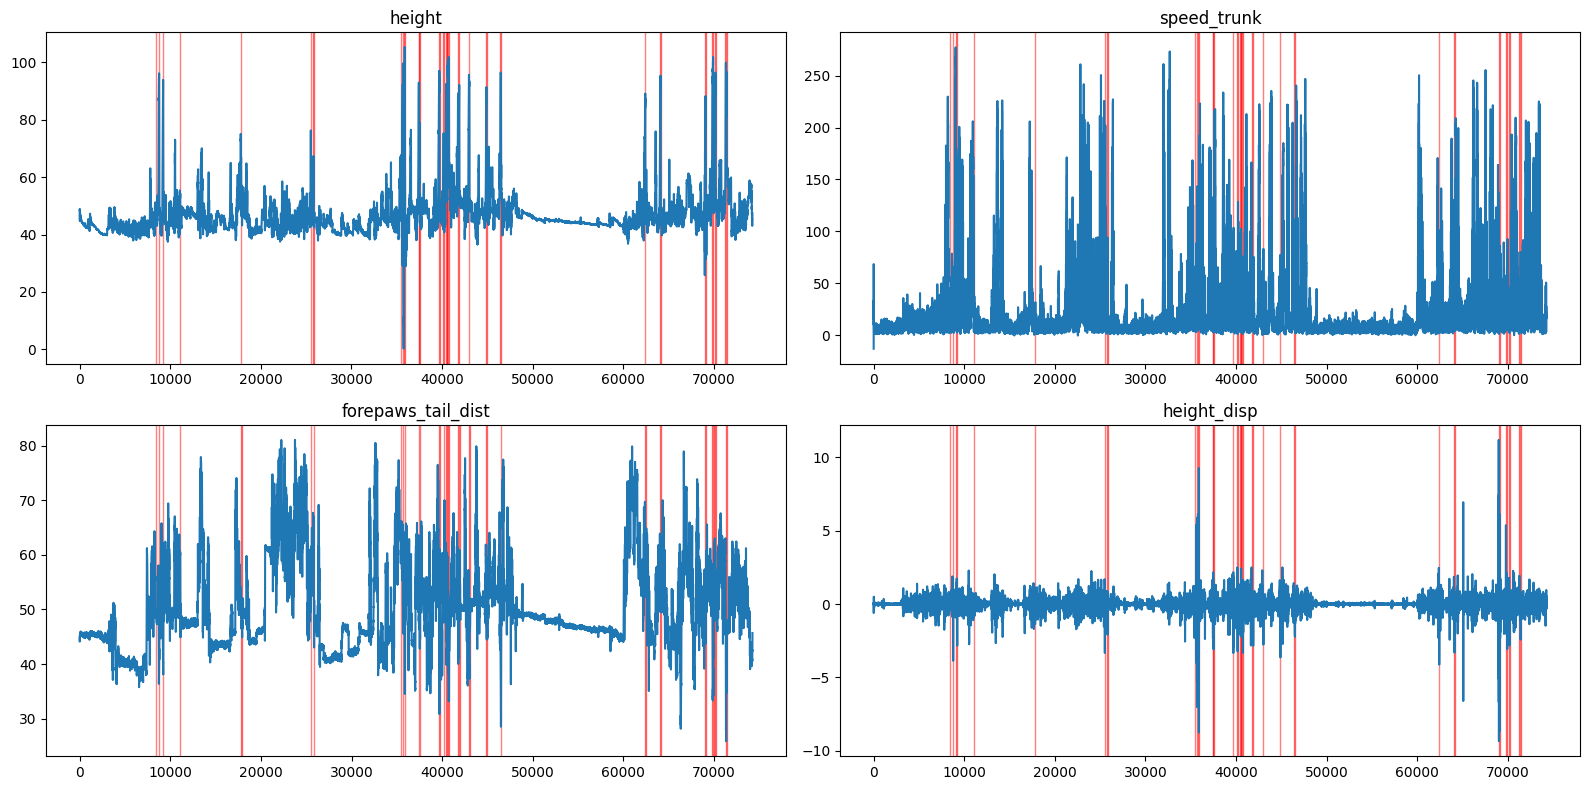

In [134]:
# viz some relationship between features
height = features_df["height"].values
speed_trunk = features_df["trunk_speed"].values
distance_forepaws_tail = features_df[["forepawL_tail_distance", "forepawR_tail_distance"]].values.mean(axis=1)
d = np.diff(height)
d = np.concatenate(([0], d))

features_arrays = {
    "height": height,
    "speed_trunk": speed_trunk,
    "forepaws_tail_dist": distance_forepaws_tail,
    "height_disp": d
}

fig, axes = plt.subplots(figsize=(16, 8), ncols=2, nrows=2)

for ax, (feature_name, feature_data) in zip(axes.flatten(), features_arrays.items()):
    ax.plot(feature_data)
    ax.set_title(feature_name)
    for idx, row in events_df[["start_frame", "end_frame"]].iterrows():
        s = row["start_frame"]
        e = row["end_frame"]
        ax.axvspan(s, e, alpha=0.5, color="red")
    # ax.set_xlim(39000, 42000)

plt.tight_layout()
plt.savefig("../plots/features_rearing_overview.png")
plt.show()


In [116]:
# generate input and labels
X = np.stack([height, distance_forepaws_tail, speed_trunk, d], axis=1)
y = np.zeros(X.shape[0])
for s, e in events_df[["start_frame", "end_frame"]].itertuples(index=False):
    y[s:e] = 1

In [117]:
events_df["duration"].mean()
#we select half of the duration as our time window:
W = 30

def build_windows_fast(X, W):
    T, F = X.shape
    # padded X: prepend W-1 rows of zeros
    pad = np.zeros((W-1, F), dtype=X.dtype)
    Xpad = np.concatenate([pad, X], axis=0)  # shape (T+W-1, F)

    # build windows via sliding strides
    X_windows = np.lib.stride_tricks.as_strided(
        Xpad,
        shape=(T, W, F),
        strides=(Xpad.strides[0], Xpad.strides[0], Xpad.strides[1])
    ).copy()

    return X_windows
X_windows = build_windows_fast(X, W)

In [118]:
P = np.argwhere(y==1).squeeze()
N = np.argwhere(y==0).squeeze()
N.shape[0] / P.shape[0]
N = N[::20]

# at some point deal with near rearing events. 
idx = np.concatenate([P, N])
np.random.shuffle(idx)

In [120]:
import torch
import torch.nn as nn

# using the prebuilt package: 
class RNNNModel(nn.Module):
    def __init__(self, input_size:int, hidden_size:int, output_size:int = 1, num_layers=1) -> None:
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        # x shape: (batch, window, 4)
        rnn_out, _ = self.rnn(x)  # rnn_out: (batch, window, hidden_size)
        last_output = rnn_out[:, -1, :]  # take last time step's output for each sequence (batch, hidden_size)
        out = self.fc(last_output)       # (batch, 1)       # (batch, 1), probability between 0 and 1
        return out

In [89]:
# buil dataset and DataLoader for training: 
from torch.utils.data import Dataset, DataLoader


class CustomDataset(Dataset):
    def __init__(self, X_windows: torch.Tensor, y: torch.Tensor) -> None:
        """
        Args:
            X_windows: Tensor of shape (num_samples, window_len, num_features)
            y: Tensor of shape (num_samples,) or (num_samples, 1)
        """
        if not isinstance(X_windows, torch.Tensor):
            X_windows = torch.Tensor(X_windows)
        if not isinstance(y, torch.Tensor):
            y = torch.Tensor(y)
        self.X = X_windows
        self.y = y
        assert self.X.shape[0] == self.y.shape[0], "Mismatch between samples in X_windows and y labels"
        self.len = self.X.shape[0]

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

    def __len__(self):
        return self.len

In [ ]:
from sklearn.model_selection import train_test_split

In [135]:
class Trainer:
    def __init__(self, model, train_dataset, test_dataset, batch_size=32, lr=1e-3, device='cpu', 
                 test_every_n_epochs=1, max_grad_norm=1.0, val_data=None, scaler=None, 
                 plot_every_n_epochs=5, save_dir='../plots'):
        self.model = model.to(device)
        self.device = device
        self.train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        self.test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.criterion = nn.BCEWithLogitsLoss()
        self.test_every_n_epochs = test_every_n_epochs
        self.max_grad_norm = max_grad_norm
        self.val_data = val_data
        self.scaler = scaler
        self.plot_every_n_epochs = plot_every_n_epochs
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(exist_ok=True)
        
        # Track loss history
        self.train_losses = []
        self.test_losses = []
        self.test_epochs = []
        self.epochs = []

    def learning_step(self, X, y):
        X, y = X.to(self.device), y.to(self.device)
        self.optimizer.zero_grad()
        output = self.model(X)
        loss = self.criterion(output.squeeze(), y.float())
        loss.backward()
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.max_grad_norm)
        self.optimizer.step()
        return loss.item()

    def test(self):
        self.model.eval()
        total_loss = 0.0
        with torch.no_grad():
            for X, y in self.test_loader:
                X, y = X.to(self.device), y.to(self.device)
                output = self.model(X)
                loss = self.criterion(output.squeeze(), y.float())
                total_loss += loss.item() * X.size(0)
        avg_loss = total_loss / len(self.test_loader.dataset)
        self.model.train()
        return avg_loss

    def plot_validation_predictions(self, epoch):
        """Generate visualization plot for validation time frame with predictions."""
        if self.val_data is None:
            return
        
        self.model.eval()
        with torch.no_grad():
            X_val = torch.Tensor(self.val_data['X_windows']).to(self.device)
            predictions = self.model(X_val)
            # Convert logits to probabilities
            probs = torch.sigmoid(predictions).cpu().numpy().squeeze()
        
        self.model.train()
        
        y_true = self.val_data['y']
        frame_indices = self.val_data['frame_indices']
        features = self.val_data['features_raw']
        val_start = frame_indices[0]
        val_end = frame_indices[-1] + 1
        
        fig, axes = plt.subplots(figsize=(16, 10), ncols=2, nrows=3)
        axes = axes.flatten()
        
        # Plot features
        feature_names = ['height', 'speed_trunk', 'forepaws_tail_dist', 'height_disp']
        for i, (ax, feat_name) in enumerate(zip(axes[:4], feature_names)):
            ax.plot(frame_indices, features[feat_name], label='Feature', alpha=0.7)
            ax.set_title(feat_name)
            ax.set_xlabel('Frame')
            ax.set_ylabel('Value')
            # Highlight ground truth events
            for idx, row in events_df[["start_frame", "end_frame"]].iterrows():
                s = row["start_frame"]
                e = row["end_frame"]
                if s < val_end and e > val_start:
                    s_plot = max(s, val_start)
                    e_plot = min(e, val_end)
                    ax.axvspan(s_plot, e_plot, alpha=0.3, color="red", label='Ground Truth' if idx == 0 else "")
            if i == 0:
                ax.legend()
        
        # Plot predictions vs ground truth
        ax_pred = axes[4]
        ax_pred.plot(frame_indices, y_true, label='Ground Truth', alpha=0.7, linewidth=2)
        ax_pred.plot(frame_indices, probs, label='Predictions (prob)', alpha=0.7, linewidth=2)
        ax_pred.set_title('Predictions vs Ground Truth')
        ax_pred.set_xlabel('Frame')
        ax_pred.set_ylabel('Probability')
        ax_pred.legend()
        ax_pred.grid(True, alpha=0.3)
        
        # Plot prediction errors
        ax_err = axes[5]
        errors = np.abs(probs - y_true)
        ax_err.plot(frame_indices, errors, label='Absolute Error', alpha=0.7, color='orange')
        ax_err.set_title('Prediction Error')
        ax_err.set_xlabel('Frame')
        ax_err.set_ylabel('|Pred - True|')
        ax_err.legend()
        ax_err.grid(True, alpha=0.3)
        
        plt.suptitle(f'Validation Predictions - Epoch {epoch}', fontsize=14, y=1.02)
        plt.tight_layout()
        
        # Save plot
        save_path = self.save_dir / f'validation_epoch_{epoch:04d}.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved validation plot to {save_path}")
        plt.show()
    
    def plot_loss_history(self):
        """Plot and save training/test loss history."""
        if len(self.train_losses) == 0:
            return
        
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(self.epochs, self.train_losses, label='Train Loss', marker='o', alpha=0.7)
        if len(self.test_losses) > 0:
            ax.plot(self.test_epochs, self.test_losses, label='Test Loss', marker='s', alpha=0.7)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title('Training and Test Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # Save plot
        save_path = self.save_dir / 'loss_history.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved loss plot to {save_path}")
        plt.show()

    def train(self, epochs=10):
        for epoch in range(epochs):
            running_loss = 0.0
            for X, y in self.train_loader:
                loss = self.learning_step(X, y)
                if np.isnan(loss):
                    print(f"NaN loss detected at epoch {epoch+1}, stopping training")
                    return
                running_loss += loss * X.size(0)
            avg_loss = running_loss / len(self.train_loader.dataset)
            self.train_losses.append(avg_loss)
            self.epochs.append(epoch + 1)
            
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f}", end="")
            if (epoch + 1) % self.test_every_n_epochs == 0:
                test_loss = self.test()
                self.test_losses.append(test_loss)
                self.test_epochs.append(epoch + 1)
                print(f" | Test Loss: {test_loss:.4f}")
            else:
                print()
            
            # Plot validation predictions periodically
            if self.val_data is not None and (epoch + 1) % self.plot_every_n_epochs == 0:
                self.plot_validation_predictions(epoch + 1)
        
        # Plot and save final loss history
        self.plot_loss_history()


NaN count: 27, Inf count: 0
Epoch 1/30 - Train Loss: 0.3299 | Test Loss: 0.1100
Epoch 2/30 - Train Loss: 0.1064 | Test Loss: 0.1004
Epoch 3/30 - Train Loss: 0.0990 | Test Loss: 0.0859
Epoch 4/30 - Train Loss: 0.0927 | Test Loss: 0.0828
Epoch 5/30 - Train Loss: 0.0887 | Test Loss: 0.0780
Saved validation plot to ../plots/validation_epoch_0005.png


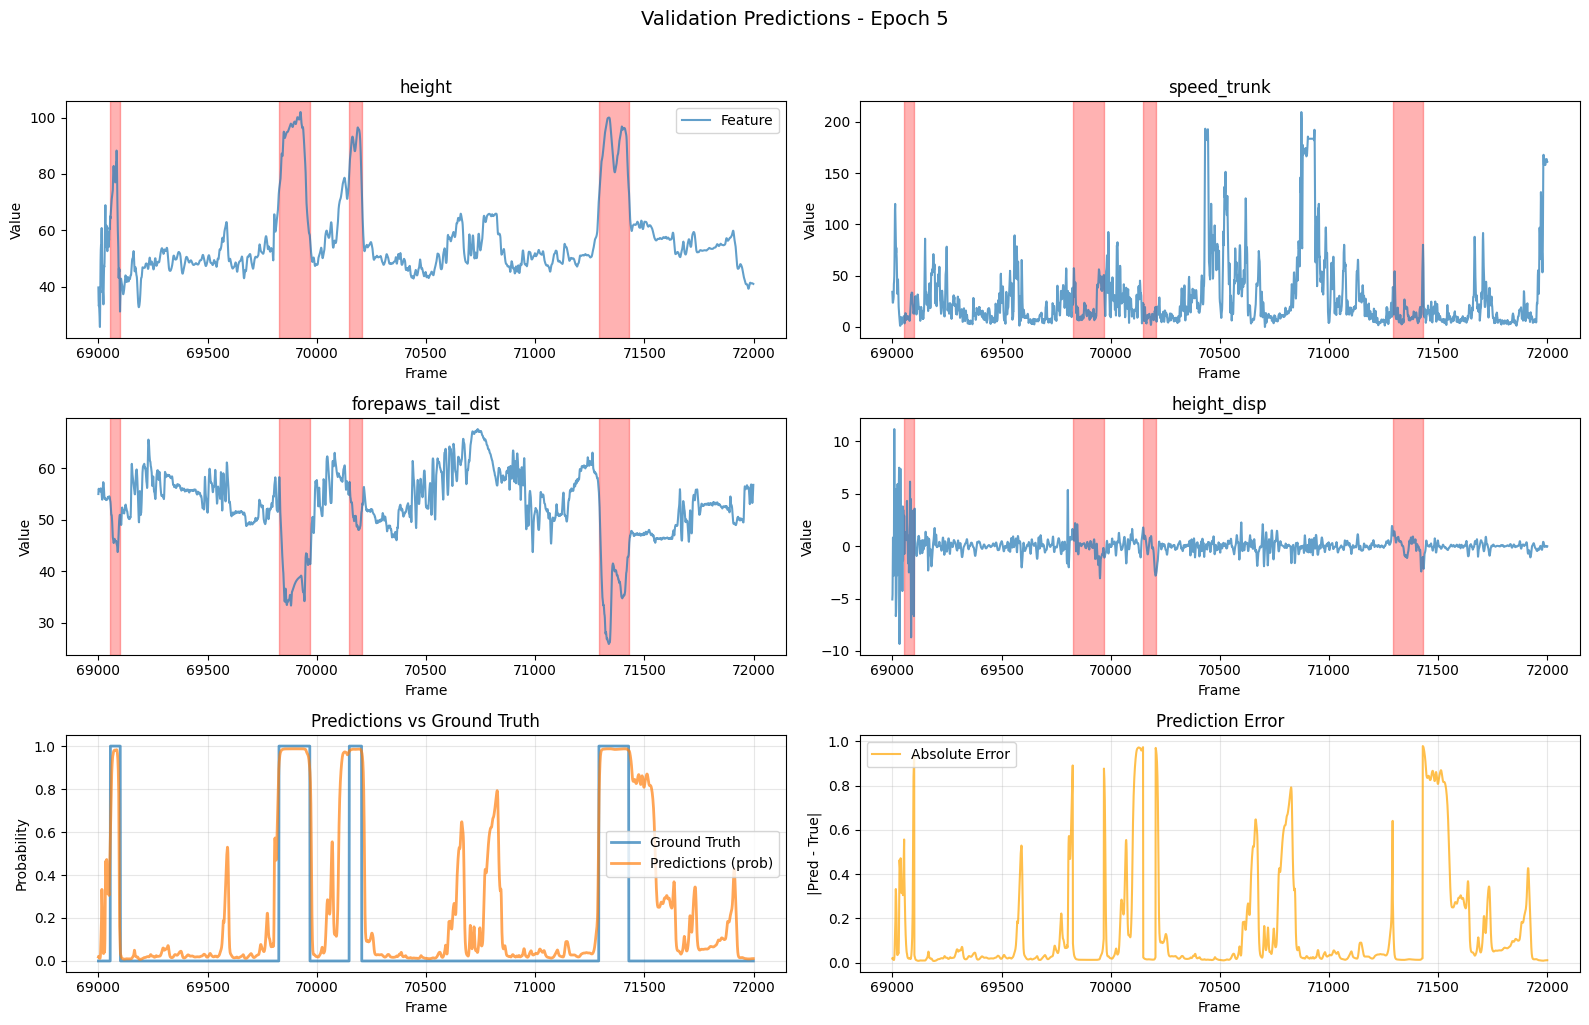

Epoch 6/30 - Train Loss: 0.0866 | Test Loss: 0.0759
Epoch 7/30 - Train Loss: 0.0854 | Test Loss: 0.0759
Epoch 8/30 - Train Loss: 0.0837 | Test Loss: 0.0699
Epoch 9/30 - Train Loss: 0.0825 | Test Loss: 0.0812
Epoch 10/30 - Train Loss: 0.0808 | Test Loss: 0.0688
Saved validation plot to ../plots/validation_epoch_0010.png


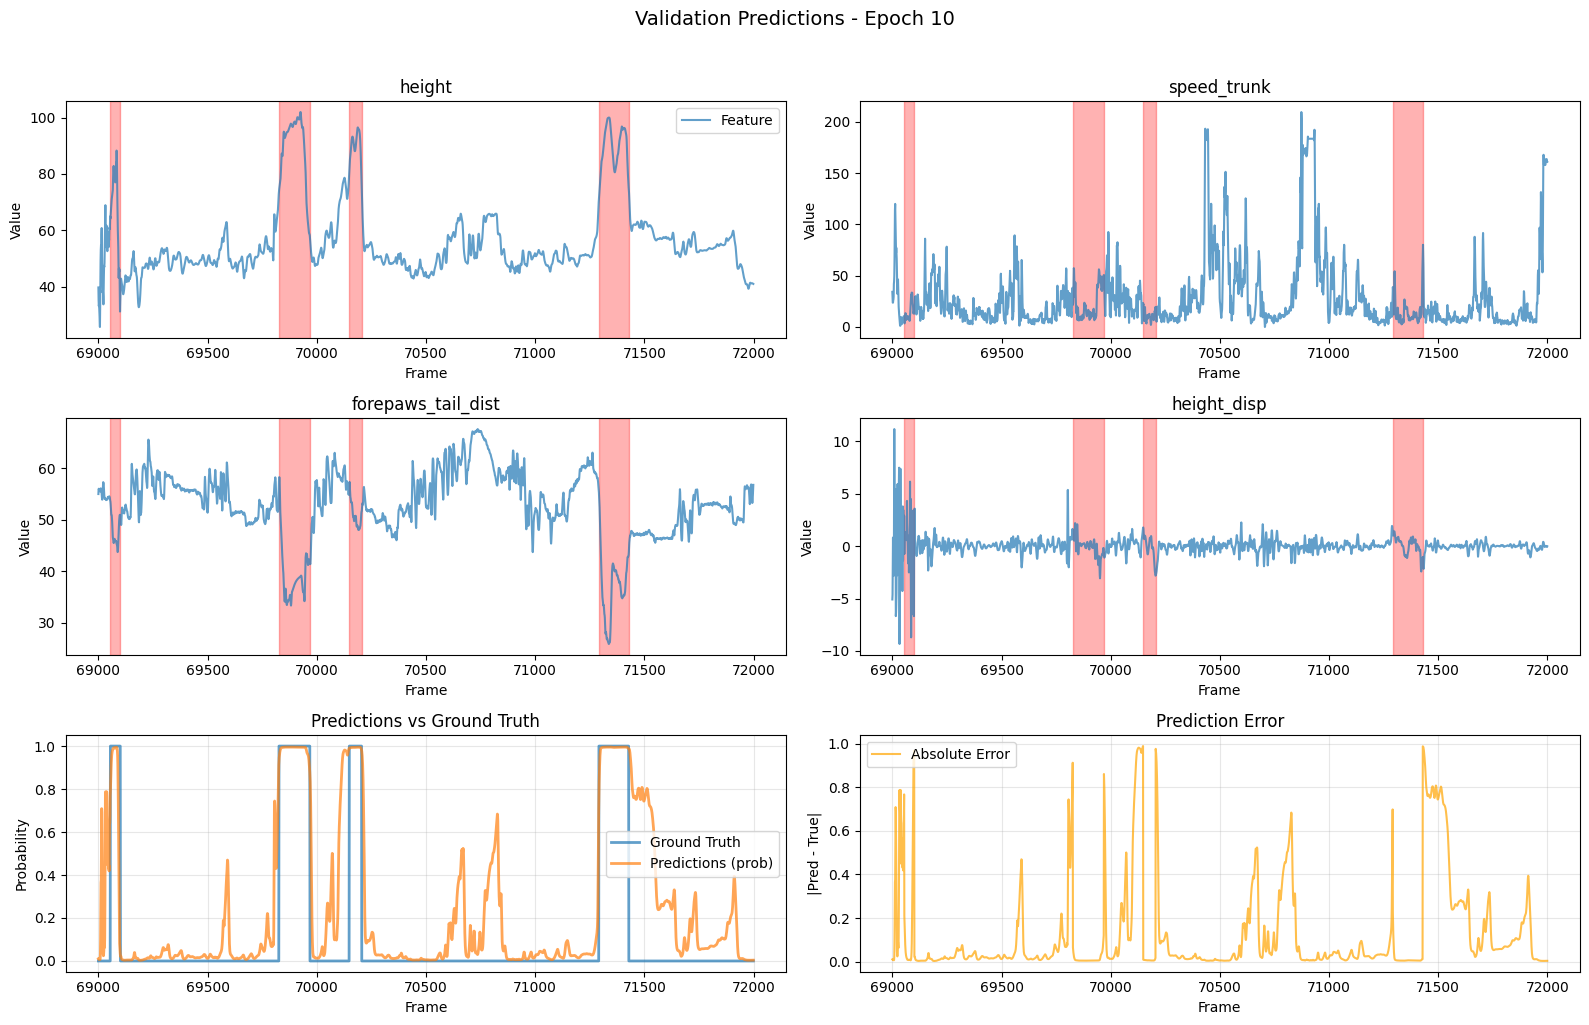

Epoch 11/30 - Train Loss: 0.0796 | Test Loss: 0.0713
Epoch 12/30 - Train Loss: 0.0791 | Test Loss: 0.0694
Epoch 13/30 - Train Loss: 0.0784 | Test Loss: 0.0658
Epoch 14/30 - Train Loss: 0.0756 | Test Loss: 0.0634
Epoch 15/30 - Train Loss: 0.0728 | Test Loss: 0.0623
Saved validation plot to ../plots/validation_epoch_0015.png


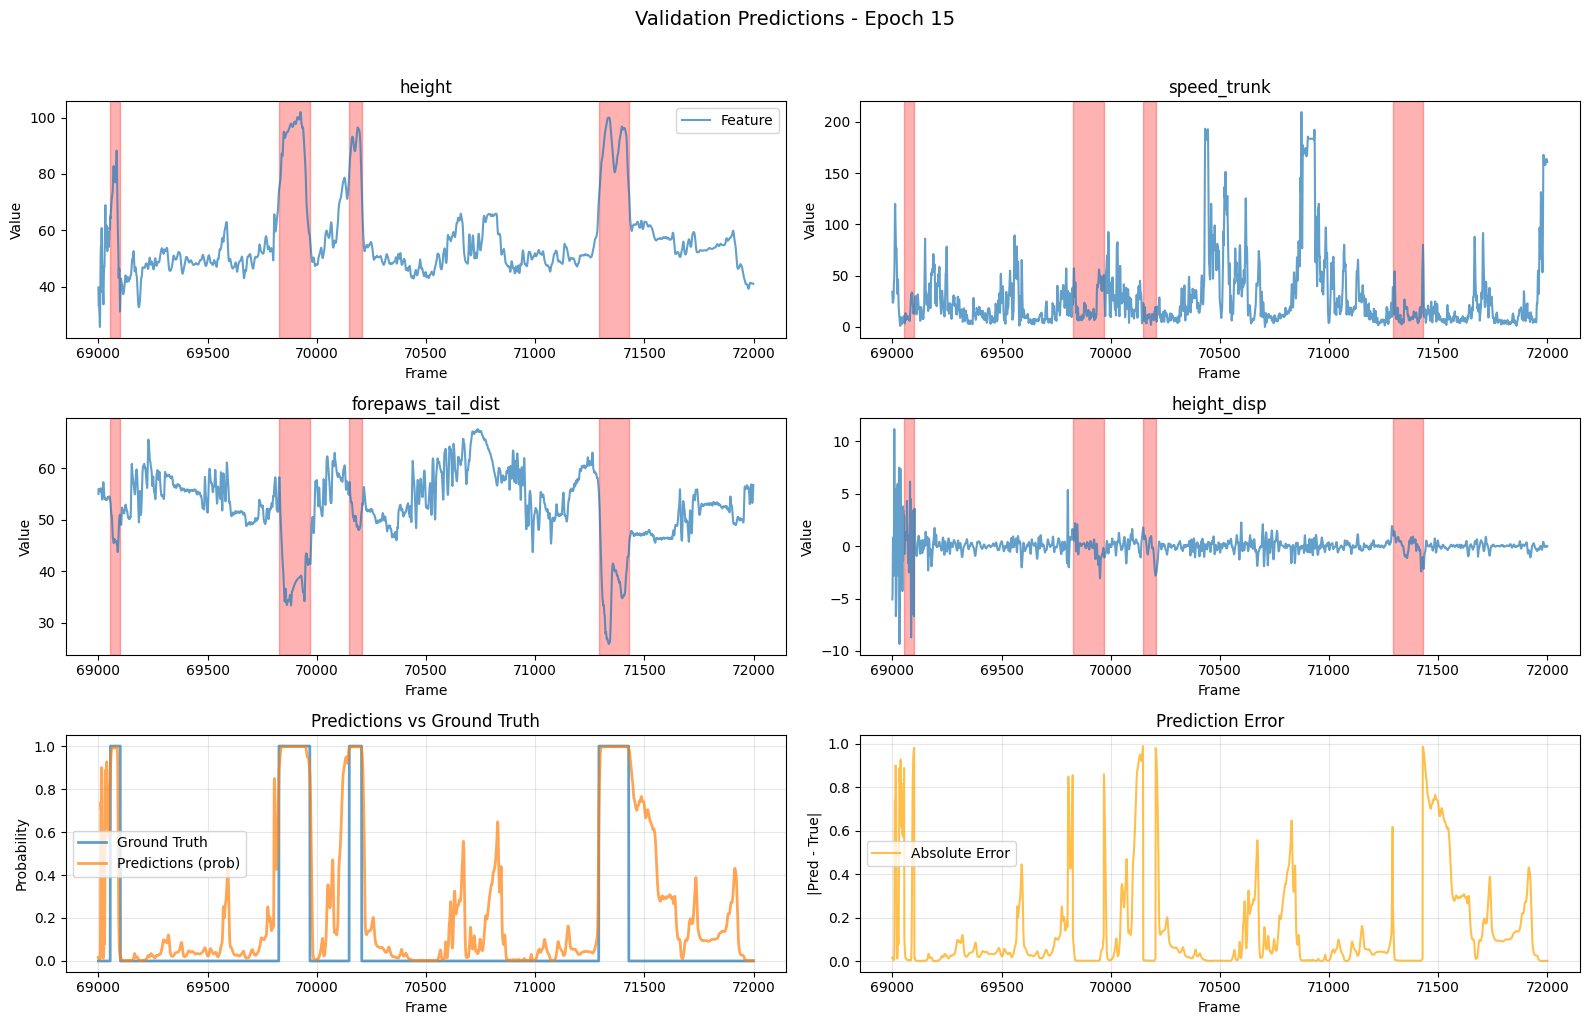

Epoch 16/30 - Train Loss: 0.0716 | Test Loss: 0.0593
Epoch 17/30 - Train Loss: 0.0676 | Test Loss: 0.0660
Epoch 18/30 - Train Loss: 0.0654 | Test Loss: 0.0626
Epoch 19/30 - Train Loss: 0.0588 | Test Loss: 0.0590
Epoch 20/30 - Train Loss: 0.0532 | Test Loss: 0.0510
Saved validation plot to ../plots/validation_epoch_0020.png


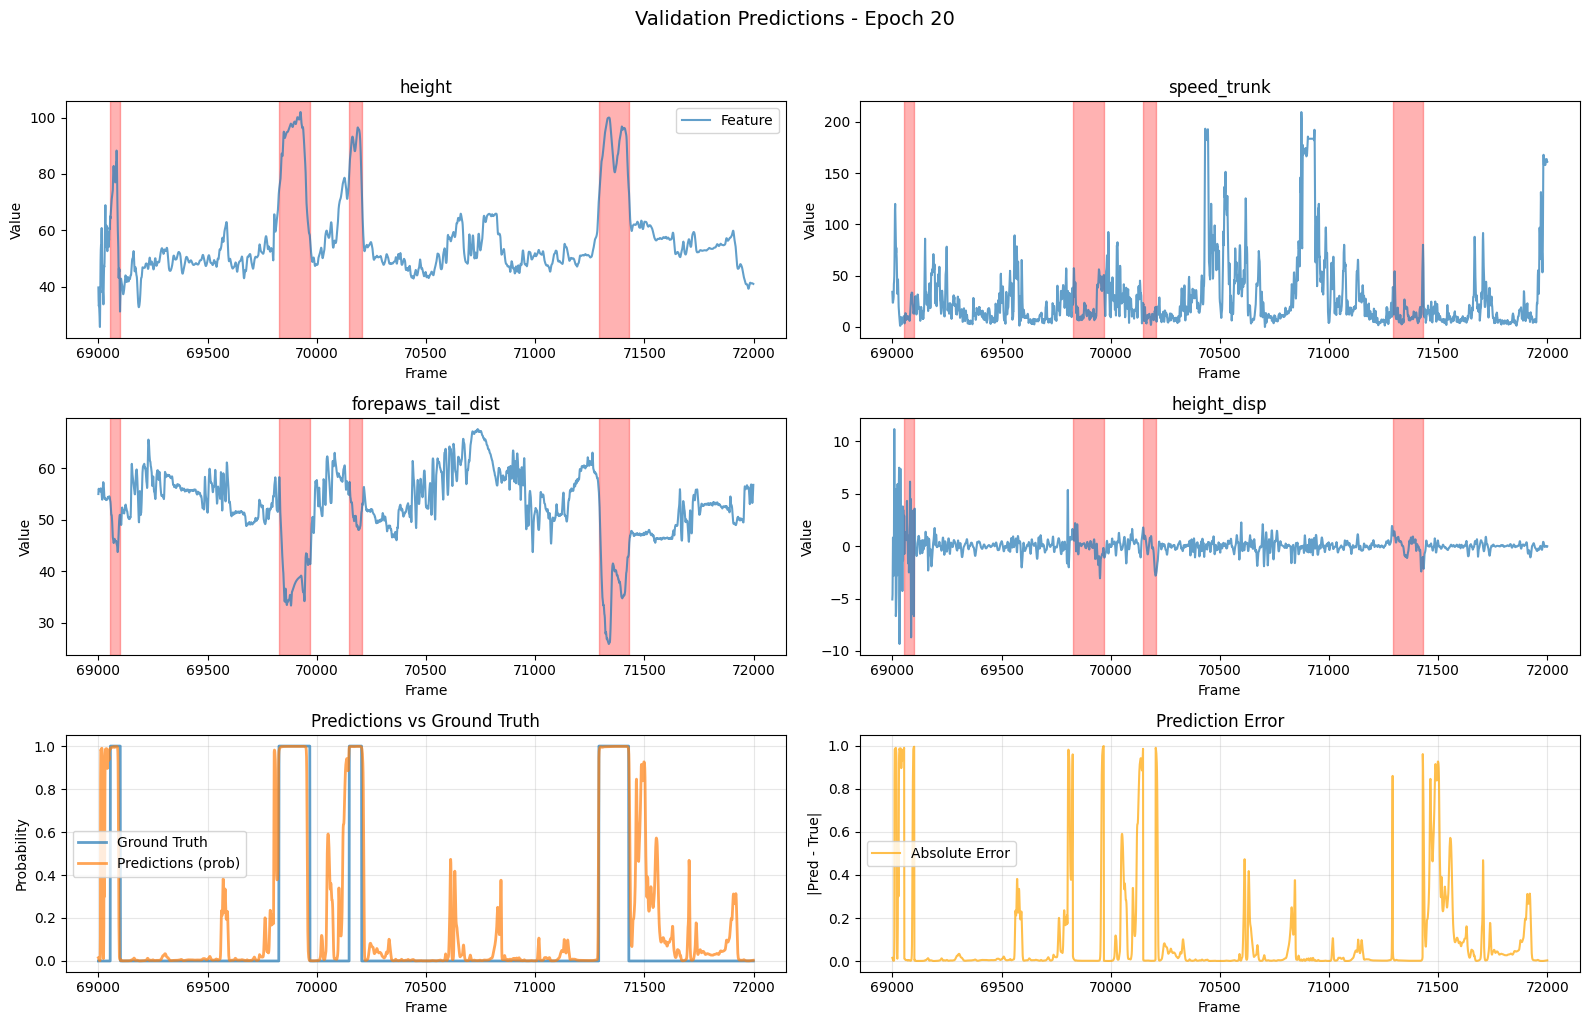

Epoch 21/30 - Train Loss: 0.0501 | Test Loss: 0.0529
Epoch 22/30 - Train Loss: 0.0456 | Test Loss: 0.0502
Epoch 23/30 - Train Loss: 0.0449 | Test Loss: 0.0487
Epoch 24/30 - Train Loss: 0.0411 | Test Loss: 0.0445
Epoch 25/30 - Train Loss: 0.0374 | Test Loss: 0.0487
Saved validation plot to ../plots/validation_epoch_0025.png


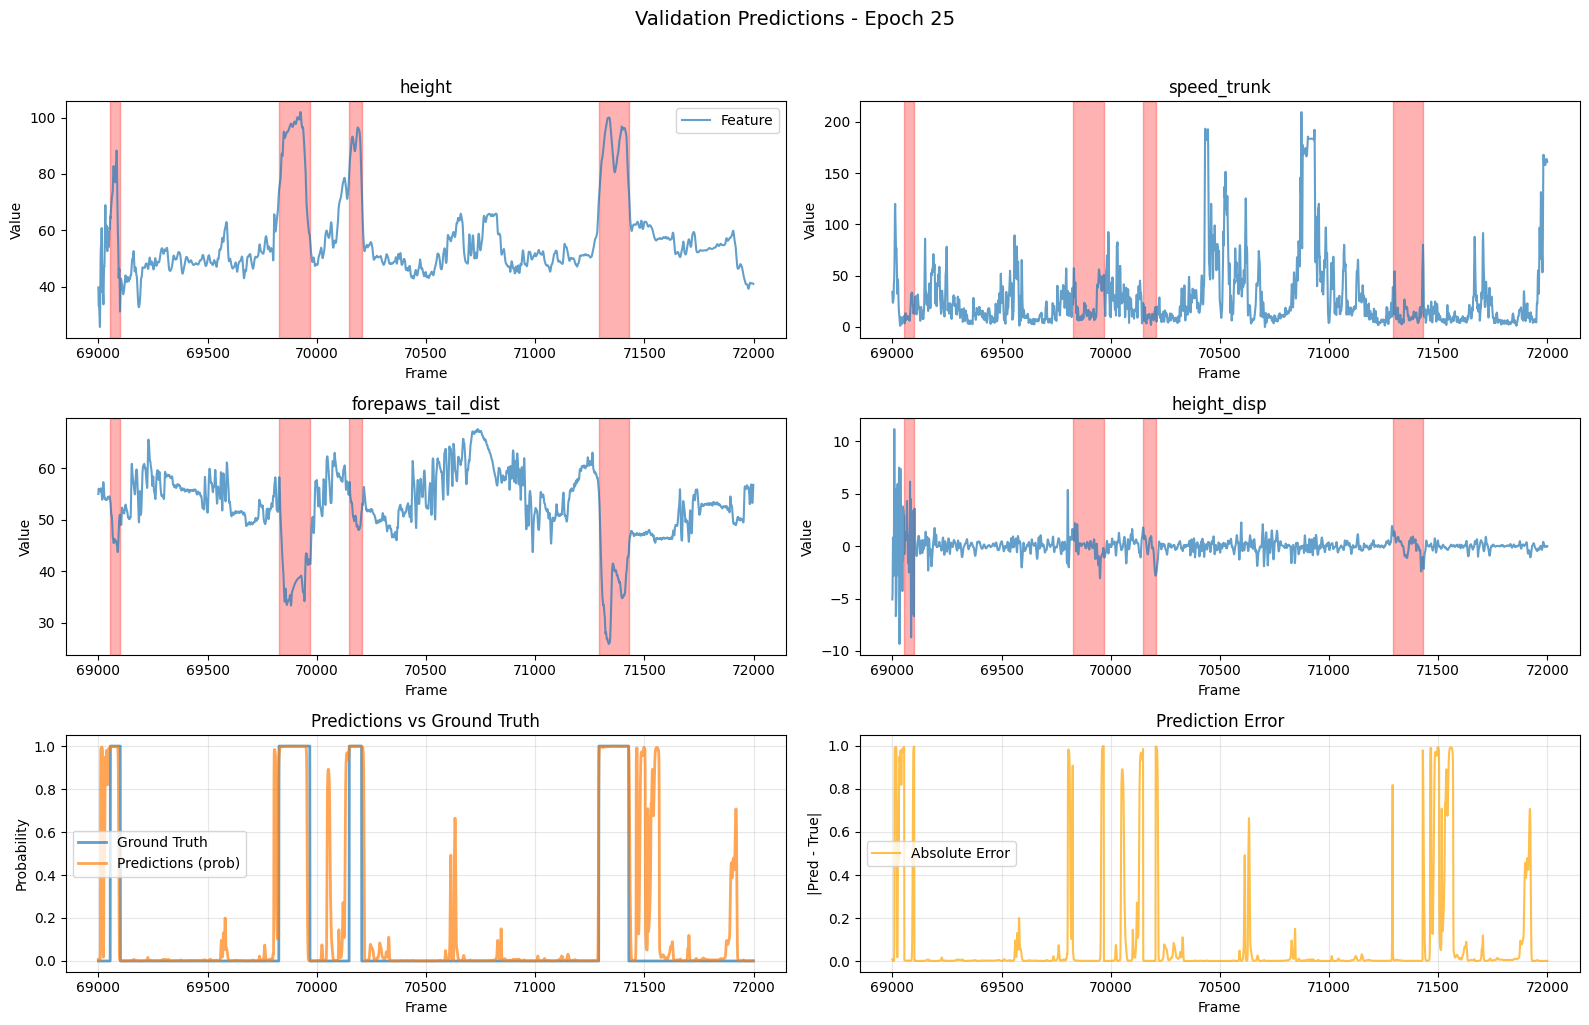

Epoch 26/30 - Train Loss: 0.0323 | Test Loss: 0.0541
Epoch 27/30 - Train Loss: 0.0314 | Test Loss: 0.0577
Epoch 28/30 - Train Loss: 0.0296 | Test Loss: 0.0508
Epoch 29/30 - Train Loss: 0.0231 | Test Loss: 0.0376
Epoch 30/30 - Train Loss: 0.0234 | Test Loss: 0.0495
Saved validation plot to ../plots/validation_epoch_0030.png


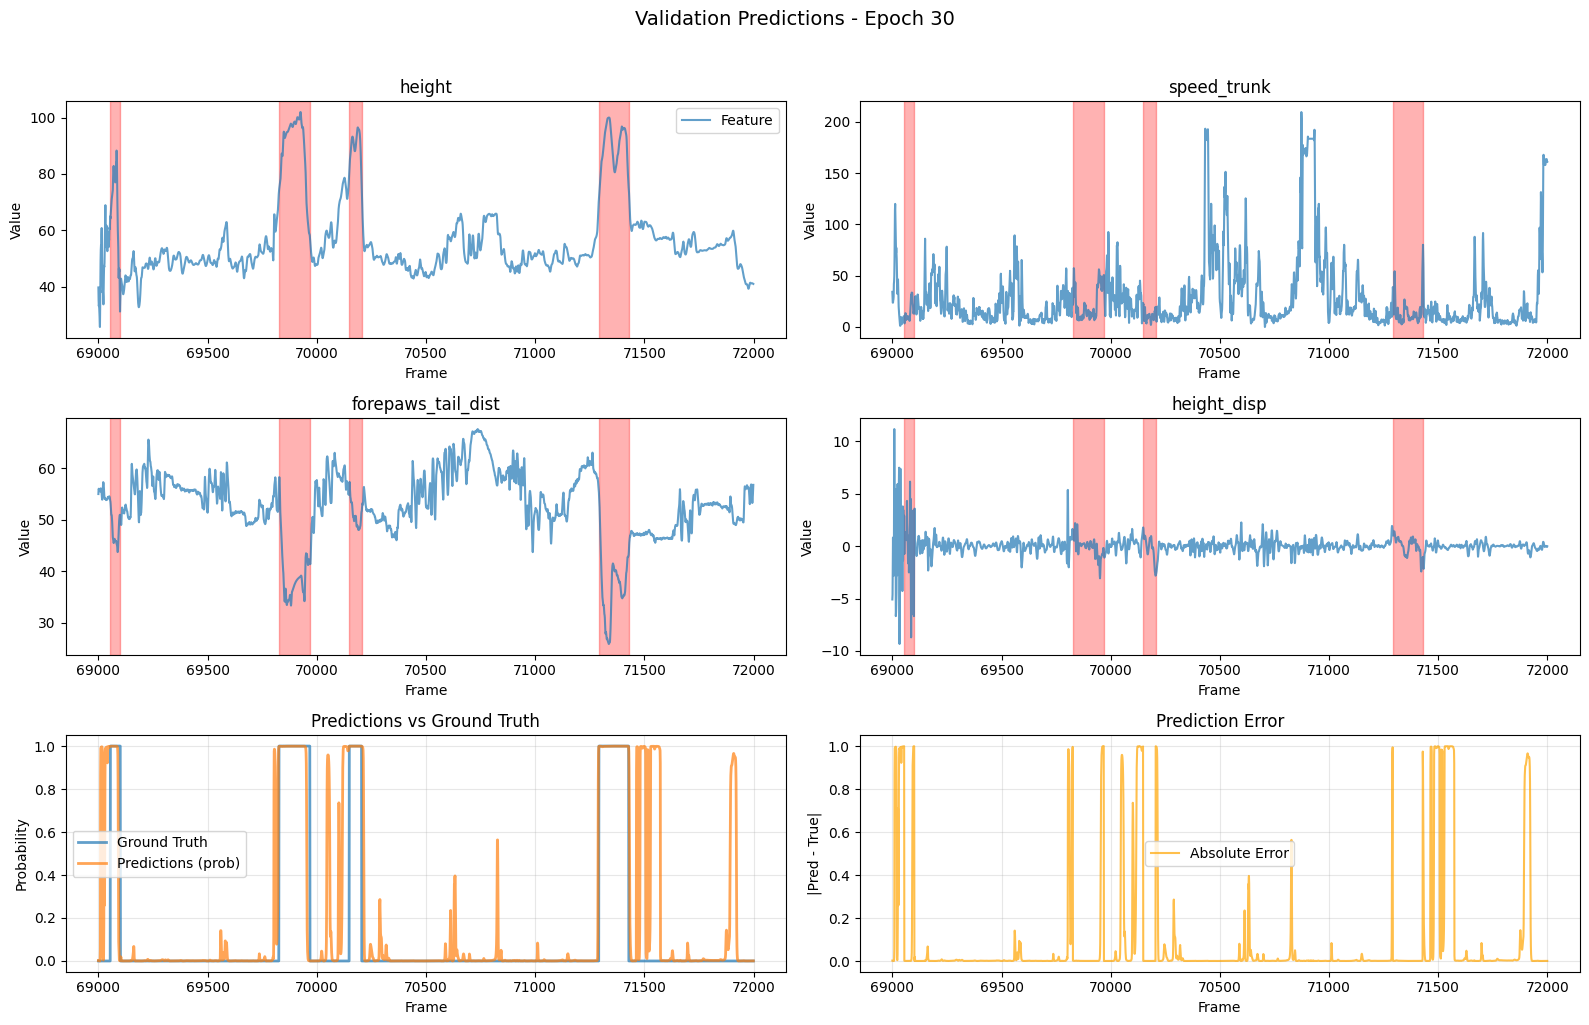

Saved loss plot to ../plots/loss_history.png


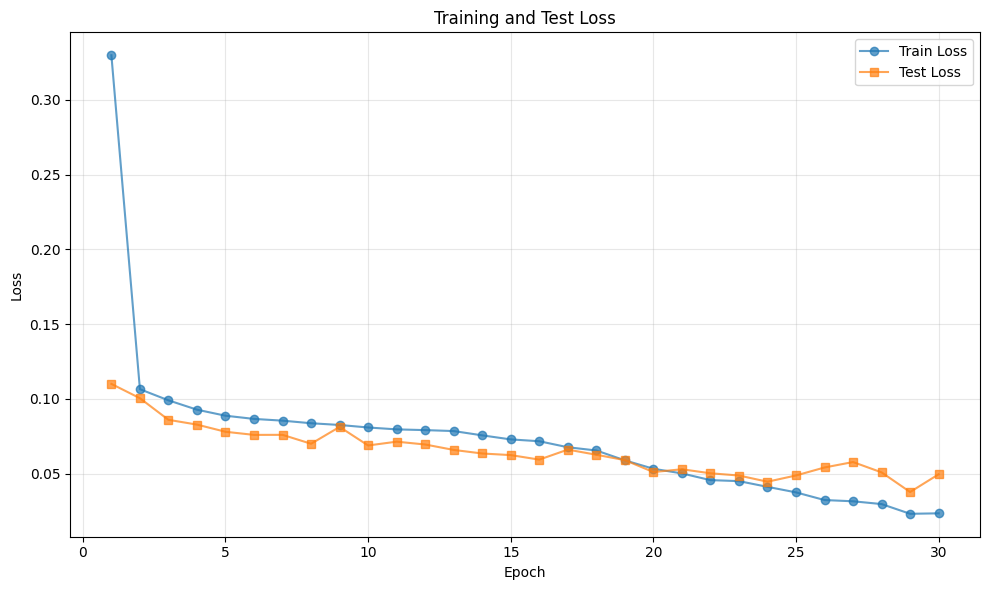

In [136]:
# generate input and labels
X = np.stack([height, distance_forepaws_tail, speed_trunk, d], axis=1)

# Check for NaN/Inf values
print(f"NaN count: {np.isnan(X).sum()}, Inf count: {np.isinf(X).sum()}")
if np.isnan(X).any() or np.isinf(X).any():
    print("WARNING: NaN/Inf detected in features!")
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Normalize features (critical for preventing NaN loss)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

y = np.zeros(X.shape[0])
for s, e in events_df[["start_frame", "end_frame"]].itertuples(index=False):
    y[s:e] = 1

# Exclude validation time frame (69000-72000) from train/test
VAL_START, VAL_END = 69000, 72000
train_mask = ~((np.arange(X.shape[0]) >= VAL_START) & (np.arange(X.shape[0]) < VAL_END))
X_train_full = X[train_mask]
y_train_full = y[train_mask]

# Store validation data with original frame indices
X_val_full = X[VAL_START:VAL_END]
y_val_full = y[VAL_START:VAL_END]
val_frame_indices = np.arange(VAL_START, VAL_END)

#we select half of the duration as our time window:
W = 30

def build_windows_fast(X, W):
    T, F = X.shape
    # padded X: prepend W-1 rows of zeros
    pad = np.zeros((W-1, F), dtype=X.dtype)
    Xpad = np.concatenate([pad, X], axis=0)  # shape (T+W-1, F)

    # build windows via sliding strides
    X_windows = np.lib.stride_tricks.as_strided(
        Xpad,
        shape=(T, W, F),
        strides=(Xpad.strides[0], Xpad.strides[0], Xpad.strides[1])
    ).copy()

    return X_windows

# Build windows for training data
X_windows_train = build_windows_fast(X_train_full, W)
y_train_full = y_train_full  # labels align with windows

# Build windows for validation data
X_windows_val = build_windows_fast(X_val_full, W)
y_val_full = y_val_full  # labels align with windows

# Sample positive and negative examples for training
P = np.argwhere(y_train_full==1).squeeze()
N = np.argwhere(y_train_full==0).squeeze()
N = N[::20]

# at some point deal with near rearing events. 
idx = np.concatenate([P, N])
np.random.shuffle(idx)

X_train_sampled, y_train_sampled = X_windows_train[idx], y_train_full[idx]
X_train, X_test, y_train, y_test = train_test_split(X_train_sampled, y_train_sampled, test_size=0.2)

train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

# Store validation data for visualization (with original features for plotting)
val_data = {
    'X_windows': X_windows_val,
    'y': y_val_full,
    'frame_indices': val_frame_indices,
    'features_raw': {
        'height': height[VAL_START:VAL_END],
        'speed_trunk': speed_trunk[VAL_START:VAL_END],
        'forepaws_tail_dist': distance_forepaws_tail[VAL_START:VAL_END],
        'height_disp': d[VAL_START:VAL_END]
    }
}

model = RNNNModel(4, hidden_size=16, num_layers=2)
device="mps"

trainer = Trainer(train_dataset=train_dataset, test_dataset=test_dataset,
    model=model, device="mps", batch_size=32, val_data=val_data, scaler=scaler, plot_every_n_epochs=5)

trainer.train(epochs=30)

In [ ]:
# test that logistic regression is not better: 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train Logistic Regression model


from sklearn.impute import SimpleImputer

# First, use only 'height' as feature
X_height = height.reshape(-1, 1)

# impute missing values (set to 0, as requested)
imputer = SimpleImputer(strategy="constant", fill_value=0)
X_height_imputed = imputer.fit_transform(X_height)

x_train_height, x_test_height, y_train_rearing, y_test_rearing = train_test_split(
    X_height_imputed, y, test_size=0.2, random_state=42
)

logistic_model_height = LogisticRegression(max_iter=1000, random_state=42).fit(x_train_height, y_train_rearing)

# Optionally: use all features (height, distance_forepaws_tail, speed_trunk, d)
X_all = np.stack([height, distance_forepaws_tail, speed_trunk, d], axis=1)
X_all_imputed = imputer.fit_transform(X_all)

x_train_all, x_test_all, y_train_all, y_test_all = train_test_split(
    X_all_imputed, y, test_size=0.2, random_state=42
)

logistic_model_all = LogisticRegression(max_iter=1000, random_state=42).fit(x_train_all, y_train_all)

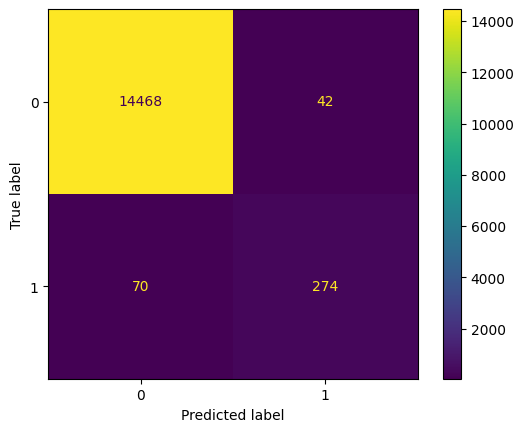

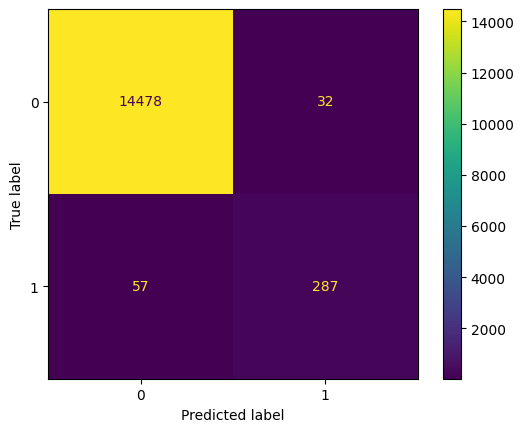

In [155]:
# chekc their performances over the test set:
classification_report(y_test_rearing, logistic_model_height.predict(x_test_height), output_dict=True)
# classification_report(y_test_rearing, logistic_model_all.predict(x_test_all), output_dict=True)
from sklearn.metrics import ConfusionMatrixDisplay

# Compute confusion matrix
cm_height = confusion_matrix(y_test_rearing, logistic_model_height.predict(x_test_height))
disp_height = ConfusionMatrixDisplay(confusion_matrix=cm_height)
disp_height.plot()
plt.show()

cm_all = confusion_matrix(y_test_rearing, logistic_model_all.predict(x_test_all))
disp_all = ConfusionMatrixDisplay(confusion_matrix=cm_all)
disp_all.plot()
plt.show()

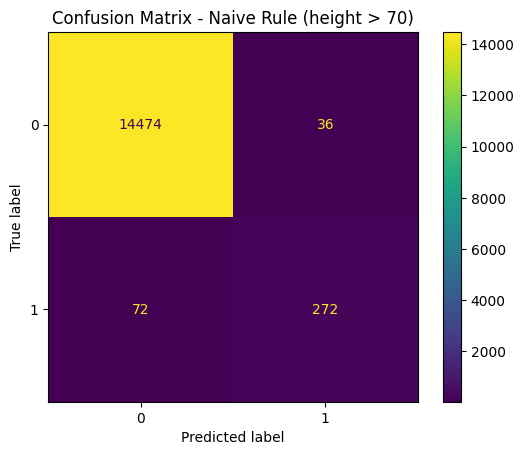

In [157]:
#  lasly I want to make a model that predicts only based on height above 70 = 1, below 70 = 0: 

# Naive rule-based model: predict 1 if height > 70, else 0

# Use test set for evaluation
y_pred_naive = (x_test_height.flatten() > 75).astype(int)

cm_naive = confusion_matrix(y_test_rearing, y_pred_naive)
disp_naive = ConfusionMatrixDisplay(confusion_matrix=cm_naive)
disp_naive.plot()
plt.title("Confusion Matrix - Naive Rule (height > 70)")
plt.show()


Saved validation features for frames 69000-72000
Logistic regression model trained on frame-level features
Raw predictions shape: (3000,)
Applied temporal smoothing
Applied hysteresis threshold (high=0.7, low=0.6)
Removed events shorter than 10 frames
Saved LR validation plot to ../plots/validation_lr.png


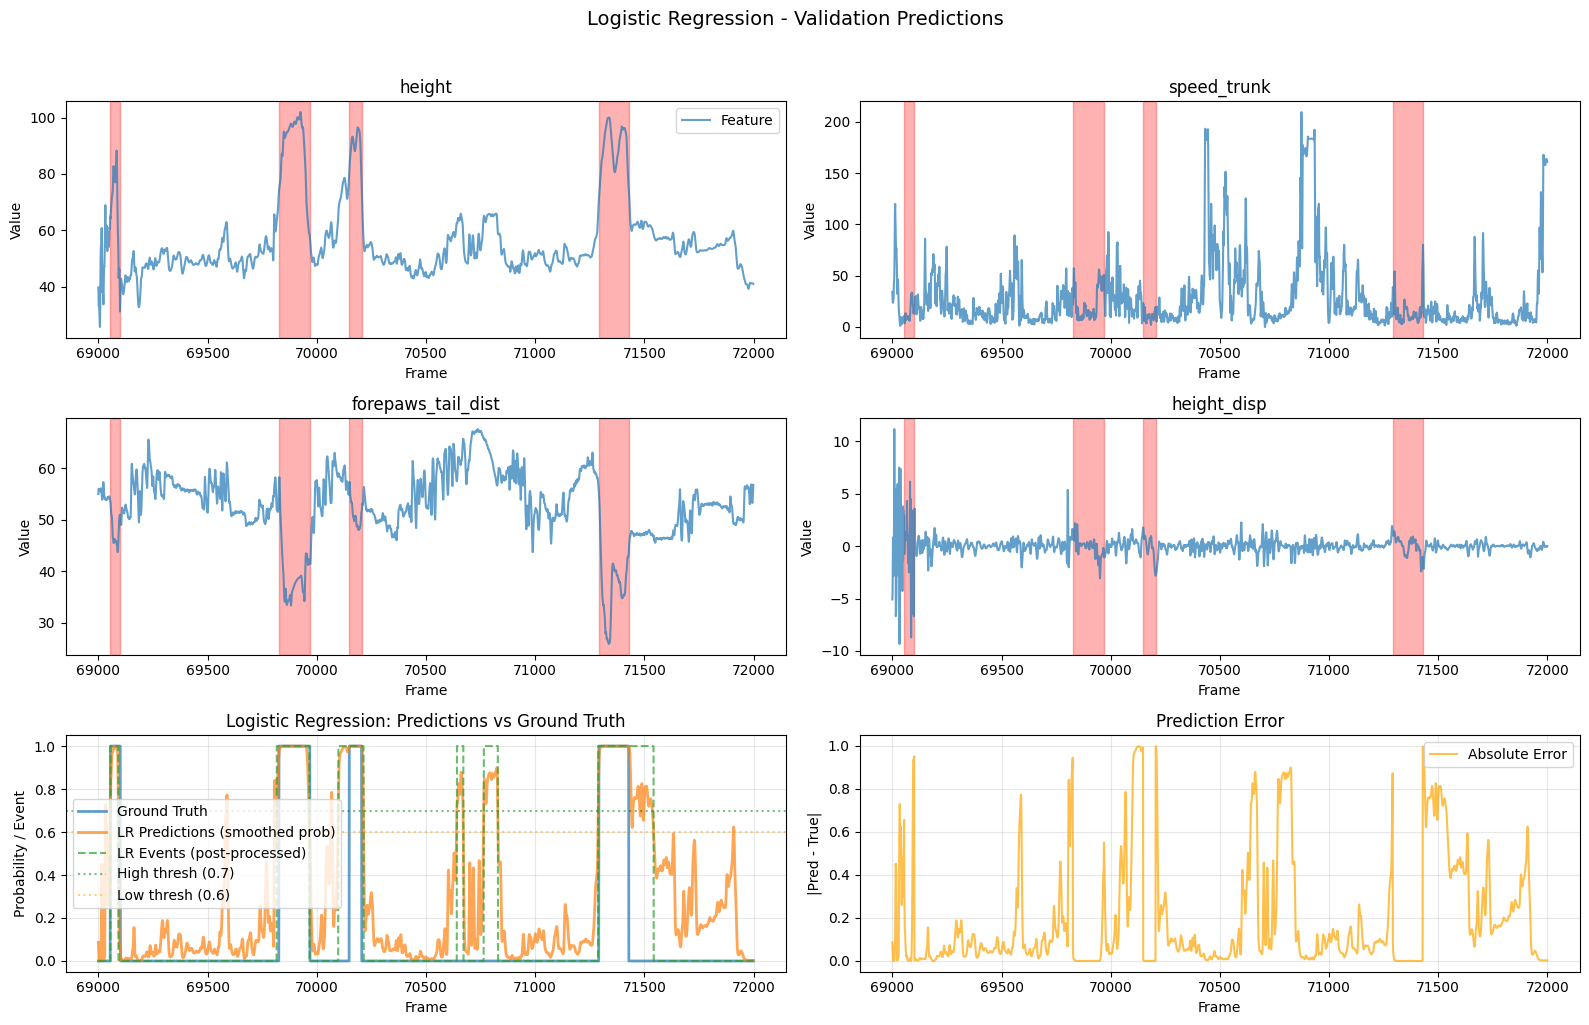

In [162]:
# Logistic Regression model with temporal post-processing
from sklearn.linear_model import LogisticRegression
from scipy.ndimage import uniform_filter1d

# Save validation features (69k-72k) for later visualization
VAL_START, VAL_END = 69000, 72000
val_features_saved = {
    'X': X_val_full.copy(),
    'y': y_val_full.copy(),
    'frame_indices': val_frame_indices.copy(),
    'features_raw': {
        'height': height[VAL_START:VAL_END].copy(),
        'speed_trunk': speed_trunk[VAL_START:VAL_END].copy(),
        'forepaws_tail_dist': distance_forepaws_tail[VAL_START:VAL_END].copy(),
        'height_disp': d[VAL_START:VAL_END].copy()
    }
}
print(f"Saved validation features for frames {VAL_START}-{VAL_END}")

# Use frame-level features (not windowed) to avoid redundancy
# Sample training data at frame level (same sampling strategy as RNN)
train_frame_indices = np.arange(len(X_train_full))
P_frames = np.argwhere(y_train_full==1).squeeze()
N_frames = np.argwhere(y_train_full==0).squeeze()
N_frames = N_frames[::20]  # Downsample negatives

idx_frames = np.concatenate([P_frames, N_frames])
np.random.shuffle(idx_frames)

X_train_lr = X_train_full[idx_frames]
y_train_lr = y_train_full[idx_frames]

# Train logistic regression on frame-level features
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_lr, y_train_lr)
print("Logistic regression model trained on frame-level features")

# Predict on validation (frame-level)
probs_raw = lr_model.predict_proba(X_val_full)[:, 1]
print(f"Raw predictions shape: {probs_raw.shape}")

# Apply temporal smoothing
smoothing_window = 5  # frames
probs_smooth = uniform_filter1d(probs_raw, size=smoothing_window, mode='nearest')
print("Applied temporal smoothing")

# Apply hysteresis threshold
def apply_hysteresis(probs, high_threshold=0.5, low_threshold=0.3):
    """Event starts above high_threshold, stops when below low_threshold"""
    events = np.zeros_like(probs, dtype=int)
    in_event = False
    
    for i in range(len(probs)):
        if not in_event:
            if probs[i] >= high_threshold:
                in_event = True
                events[i] = 1
        else:
            if probs[i] < low_threshold:
                in_event = False
            else:
                events[i] = 1
    
    return events

high_thresh = 0.7
low_thresh = 0.6
events_hysteresis = apply_hysteresis(probs_smooth, high_threshold=high_thresh, low_threshold=low_thresh)
print(f"Applied hysteresis threshold (high={high_thresh}, low={low_thresh})")

# Drop very short events (less than min_duration frames)
def remove_short_events(events, min_duration=10):
    """Remove events shorter than min_duration frames"""
    events_cleaned = events.copy()
    
    # Find event boundaries
    diff = np.diff(np.concatenate(([0], events_cleaned, [0])))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]
    
    # Remove short events
    for start, end in zip(starts, ends):
        if end - start < min_duration:
            events_cleaned[start:end] = 0
    
    return events_cleaned

min_duration = 10
events_final = remove_short_events(events_hysteresis, min_duration=min_duration)
print(f"Removed events shorter than {min_duration} frames")

# Create the same plot as RNN model
fig, axes = plt.subplots(figsize=(16, 10), ncols=2, nrows=3)
axes = axes.flatten()

# Plot features
feature_names = ['height', 'speed_trunk', 'forepaws_tail_dist', 'height_disp']
for i, (ax, feat_name) in enumerate(zip(axes[:4], feature_names)):
    ax.plot(val_frame_indices, val_features_saved['features_raw'][feat_name], label='Feature', alpha=0.7)
    ax.set_title(feat_name)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Value')
    # Highlight ground truth events
    for idx, row in events_df[["start_frame", "end_frame"]].iterrows():
        s = row["start_frame"]
        e = row["end_frame"]
        if s < VAL_END and e > VAL_START:
            s_plot = max(s, VAL_START)
            e_plot = min(e, VAL_END)
            ax.axvspan(s_plot, e_plot, alpha=0.3, color="red", label='Ground Truth' if idx == 0 else "")
    if i == 0:
        ax.legend()

# Plot predictions vs ground truth
ax_pred = axes[4]
ax_pred.plot(val_frame_indices, y_val_full, label='Ground Truth', alpha=0.7, linewidth=2)
ax_pred.plot(val_frame_indices, probs_smooth, label='LR Predictions (smoothed prob)', alpha=0.7, linewidth=2)
ax_pred.plot(val_frame_indices, events_final, label='LR Events (post-processed)', alpha=0.7, linewidth=1.5, linestyle='--')
ax_pred.axhline(y=high_thresh, color='green', linestyle=':', alpha=0.5, label=f'High thresh ({high_thresh})')
ax_pred.axhline(y=low_thresh, color='orange', linestyle=':', alpha=0.5, label=f'Low thresh ({low_thresh})')
ax_pred.set_title('Logistic Regression: Predictions vs Ground Truth')
ax_pred.set_xlabel('Frame')
ax_pred.set_ylabel('Probability / Event')
ax_pred.legend()
ax_pred.grid(True, alpha=0.3)

# Plot prediction errors
ax_err = axes[5]
errors = np.abs(probs_smooth - y_val_full)
ax_err.plot(val_frame_indices, errors, label='Absolute Error', alpha=0.7, color='orange')
ax_err.set_title('Prediction Error')
ax_err.set_xlabel('Frame')
ax_err.set_ylabel('|Pred - True|')
ax_err.legend()
ax_err.grid(True, alpha=0.3)

plt.suptitle('Logistic Regression - Validation Predictions', fontsize=14, y=1.02)
plt.tight_layout()

# Save plot
save_path = Path('../plots/validation_lr.png')
save_path.parent.mkdir(exist_ok=True)
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved LR validation plot to {save_path}")
plt.show()

